In [83]:
import pandas as pd
import numpy as np
from itertools import product, combinations
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from pylatexenc.latexencode import unicode_to_latex as text2latex
from scipy import stats


sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.helpers import make_aesthetic, cat_stats
from src.statsmodels_handler import StatsmodelsHandler, clean_var_name_from_formula
import random

random.seed(42)
np.random.seed(42)

mypal = make_aesthetic()


def make_bold(x):
	"""
	This function is used to make part of the title bold like as a subtitle.
	Basically, it's using latex to render a (sub)string bold in matplot.
	But make_aesthetic() should handle using Arial for math font,
	so it won't look weird.
	>>> full_title = f"{make_bold("Regression Coefficients of Estimated Prevalence From Multiverse")}\n(Baseline is raw data with no weighting and no dropping)"

	"""
	#
	words = x.split()
	words = ' \\ '.join([w for w in words])  # Escape backslash properly
	bold_str = f"$\\bf{{{words}}}$"  # Correctly format the f-string
	return bold_str

def did_use(x):
    if "never" in x.lower():
        return 0
    else:
        return 1

def short_domain(x):
    if "convention" in x.lower():
        return "conventional"
    elif "moral" in x.lower():
        return "moral"
    elif "personal" in x.lower():
        return "personal"
    else:
        return "other"

df = pd.read_csv("../data/qualtrics_experiments/desc_norms_interface [typing]_August 23, 2025_20.20.csv")
# print(sorted(df.columns))
df = df.iloc[2:]
df = df.query("DistributionChannel=='anonymous'") # this will remove reponses from using preview link

data_pts = []
for i, row in df.iterrows():
    # non_loop_merge_vars
    base_pt = {
        "pid": row['ResponseId'],
        "progress": row['Progress'],
        "duration": float(row['Duration (in seconds)'])/60,
        "finished": row['Finished'],
        "feedback": row['feedback'],
        "llm_usage": row['dv_llm_usage'],
        "usage_convention": row['dv_usage_convention'],
        "usage_moral": row['dv_usage_moral'],
        "usage_personal": row['dv_usage_personal'],
        "llm_usage_binary": did_use(row['dv_llm_usage']),
        "usage_convention_binary": did_use(row['dv_usage_convention']),
        "usage_moral_binary": did_use(row['dv_usage_moral']),
        "usage_personal_binary": did_use(row['dv_usage_personal']),
    }

    # loop and merge columns:
    for i in range(1, 60):
        pre = float(row.get(f'{i}_lm_pre_11'))
        post =float( row.get(f'{i}_lm_post_11'))
        qual = row.get(f'{i}_lm_qual')
        if pd.notnull(pre) and pd.notnull(post):
            data_pt = base_pt.copy()
            data_pt['idx'] = i
            data_pt['pre'] = pre
            data_pt['post'] = post
            data_pt['qual'] = qual
            data_pts.append(data_pt)


# We get a long dataframe with one row per trial per person
df = pd.DataFrame(data_pts)


# Merge in metadata
#############################################
#############################################
meta_df = pd.read_csv("../data/clean/ai_rot_stimuli_new_prompt.csv")
df = df.merge(meta_df, on='idx', how='left')
#############################################
#############################################

# Clean and process
#############################################
#############################################

# Distance stuff
df['pre_distance'] = np.abs(df['pre'] - df['rating'])
df['post_distance'] = np.abs(df['post'] - df['rating'])
df['change_distance'] = df['pre_distance'] - df['post_distance']

# Domain cleaning
df['domain'] = df['domain'].map(short_domain)


# Usage cleaning
usage_map = {
   "No - never used": 0,
   "Yes - less often than several times a week": 1,
   "Yes - several times a week": 2,
   "Yes - about once a day": 3,
   "Yes - several times a day": 4
}
for var in ['usage_personal', 'usage_moral', 'usage_convention']:
    df[f"{var}_int"] = df[var].map(usage_map)
df['usage_sum'] = df[['usage_personal_int', 'usage_moral_int', 'usage_convention_int']].sum(axis=1)

df.to_csv("../data/qualtrics_experiments/desc_norms_init_norm_pilot_long.csv", index=False)
#############################################
#############################################

 # Descriptives of change

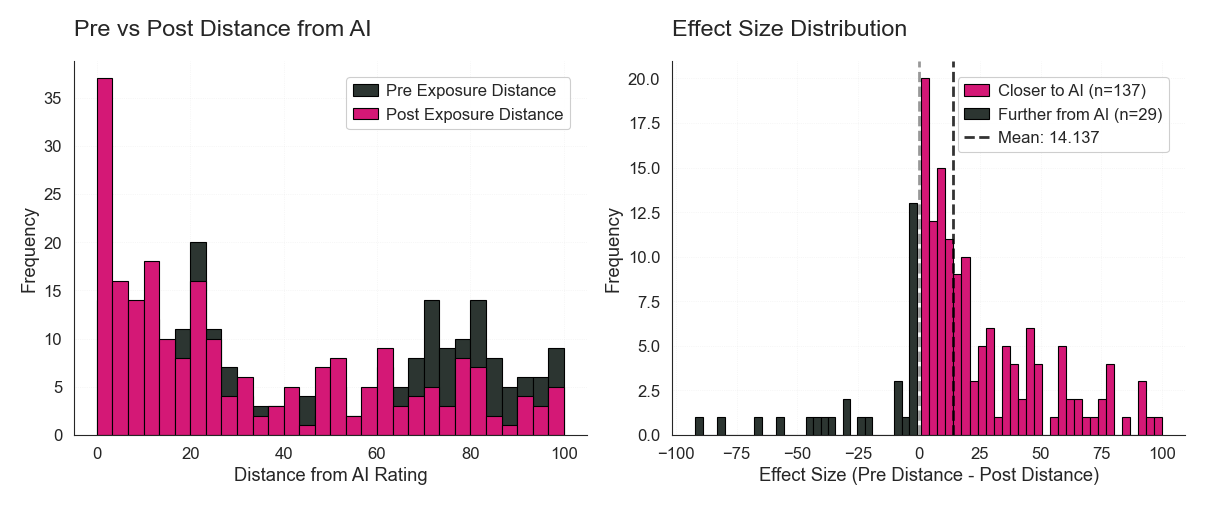


    The mean effect (pre-distance minus post-distance) was 14.14 (SD = 28.42) on an agreement scale of 0-100, with a Cohen's dz of 0.50 (95% CI [0.37, 0.64]), Wilcoxon signed-rank test W = 1886.5, p = 4.1e-16. In 61% of cases, participants moved closer to the AI rating, while in 13% of cases they moved further away, and in 27% of cases there was no change. 


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from src.helpers import array_stats

mypal = make_aesthetic(font_scale=1.2)
effect_size = df['pre_distance'] - df['post_distance']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#################################################################
# Pre_distance and post_distance as overlaid histograms
#################################################################
ax1 = axes[0]
ax1.hist(df['pre_distance'], bins=30, alpha=1, label='Pre Exposure Distance',  edgecolor='black')
ax1.hist(df['post_distance'], bins=30, alpha=1, label='Post Exposure Distance', edgecolor='black')
ax1.set_xlabel('Distance from AI Rating')
ax1.set_ylabel('Frequency')
ax1.set_title('Pre vs Post Distance from AI')
ax1.legend()
ax1.grid(True, alpha=0.3)

#################################################################
# Distribution of effect sizes
#################################################################
ax2 = axes[1]
closer_to_ai = effect_size[effect_size > 0]
further_from_ai = effect_size[effect_size < 0]

ax2.hist(closer_to_ai, bins=30, alpha=1, label=f'Closer to AI (n={len(closer_to_ai)})',
color=mypal[1], edgecolor='black')
ax2.hist(further_from_ai, bins=30, alpha=1, label=f'Further from AI (n={len(further_from_ai)})',
         color=mypal[0], edgecolor='black')
ax2.axvline(0, color='gray', linestyle='--', alpha=0.8, linewidth=2)
ax2.axvline(effect_size.mean(), color='black', linestyle='--', alpha=0.8, linewidth=2,
            label=f'Mean: {effect_size.mean():.3f}')

ax2.set_xlabel('Effect Size (Pre Distance - Post Distance)')
ax2.set_ylabel('Frequency')
ax2.set_title('Effect Size Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


######################################
# Statistics
######################################
def bootstrap_dz(data, n_bootstraps=10000):
    boot_dz = []
    n = len(data)
    for i in range(n_bootstraps):
        sample = np.random.choice(data, size=n, replace=True)
        mean_diff = np.mean(sample)
        sd_diff = np.std(sample, ddof=1)
        if sd_diff != 0:
            boot_dz.append(mean_diff / sd_diff)
    return np.percentile(boot_dz, [2.5, 97.5])

def compute_change_metrics(pre, post):
    effect_size = pre - post
    mean_diff = effect_size.mean()
    sd_diff = effect_size.std()
    cohens_dz = mean_diff / sd_diff
    ci_lower, ci_upper = bootstrap_dz(effect_size)
    moved_closer = effect_size > 0
    moved_further = effect_size < 0
    no_change = effect_size == 0
    wilcox_w = stats.wilcoxon(pre, post)

    # Calculate percentages
    n = len(effect_size)
    percent_closer = moved_closer.sum() / n
    percent_further = moved_further.sum() / n
    percent_no_change = no_change.sum() / n

    data =  {
        "mean_diff": mean_diff,
        "sd_diff": sd_diff,
        "cohens_dz": cohens_dz,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "moved_closer": moved_closer,
        "moved_further": moved_further,
        "no_change": no_change,
        "wilcox_w": wilcox_w.statistic,
        "wilcox_p": wilcox_w.pvalue
    }
    stats_str = f"""
    The mean effect (pre-distance minus post-distance) was {mean_diff:.2f} (SD = {sd_diff:.2f}) on an agreement scale of 0-100, with a Cohen's dz of {cohens_dz:.2f} (95% CI [{ci_lower:.2f}, {ci_upper:.2f}]), Wilcoxon signed-rank test W = {wilcox_w.statistic}, p = {wilcox_w.pvalue:.1e}. In {percent_closer*100:.0f}% of cases, participants moved closer to the AI rating, while in {percent_further*100:.0f}% of cases they moved further away, and in {percent_no_change*100:.0f}% of cases there was no change. """
    print(stats_str)
    return data

metrics = compute_change_metrics(df['pre_distance'], df['post_distance'])



# By factors

## Descriptive plots

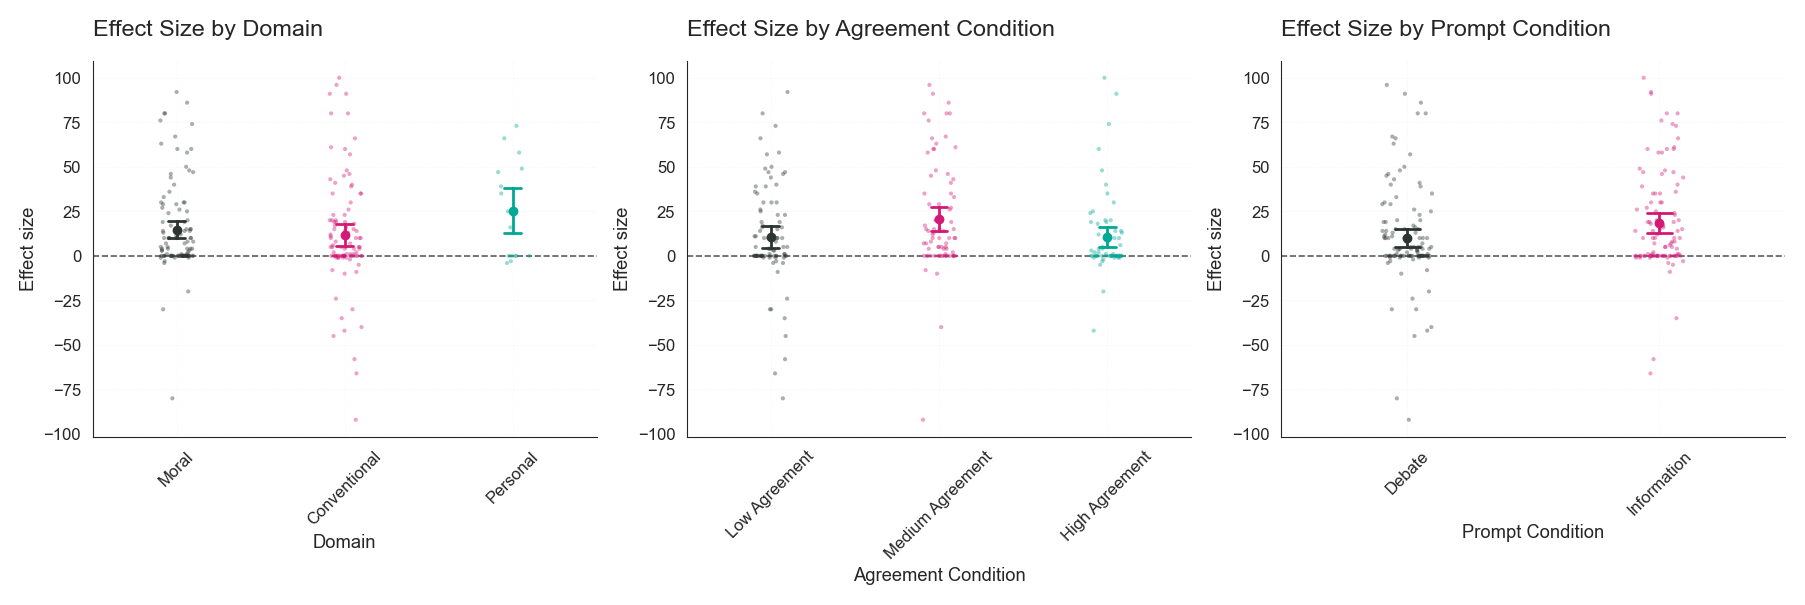

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


#############################################
# Grid plot by factors
#############################################
mypal = make_aesthetic(font_scale=1.2)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
mypal = make_aesthetic(font_scale=1.2)
factors = ['domain', 'agreement_condition', 'prompt_condition']
factor_titles = ['Domain', 'Agreement Condition', 'Prompt Condition']

for i, (factor, title) in enumerate(zip(factors, factor_titles)):
    ax = axes[i]

    sns.pointplot(x=factor, y='change_distance', data=df, palette=mypal,
                 capsize=0.1, errwidth=2, ax=ax)

    sns.stripplot(x=factor, y='change_distance', data=df, palette=mypal,
                 alpha=0.4, size=3, ax=ax)

    ax.axhline(y=0, color='k', linestyle='--', alpha=0.7)

    labels = [label.get_text().replace('_', ' ').title() for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels, rotation=45)

    ax.set_title(f"Effect Size by {title}")
    ax.set_ylabel("Effect size")
    ax.set_xlabel(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#############################################
#############################################

## Mixed effects model

                                            Mixed Linear Model Regression Results
Model:                                   MixedLM                      Dependent Variable:                      change_distance
No. Observations:                        226                          Method:                                  REML           
No. Groups:                              1                            Scale:                                   681.9786       
Min. group size:                         226                          Log-Likelihood:                          -1050.2178     
Max. group size:                         226                          Converged:                               Yes            
Mean group size:                         226.0                                                                                
------------------------------------------------------------------------------------------------------------------------------
                             

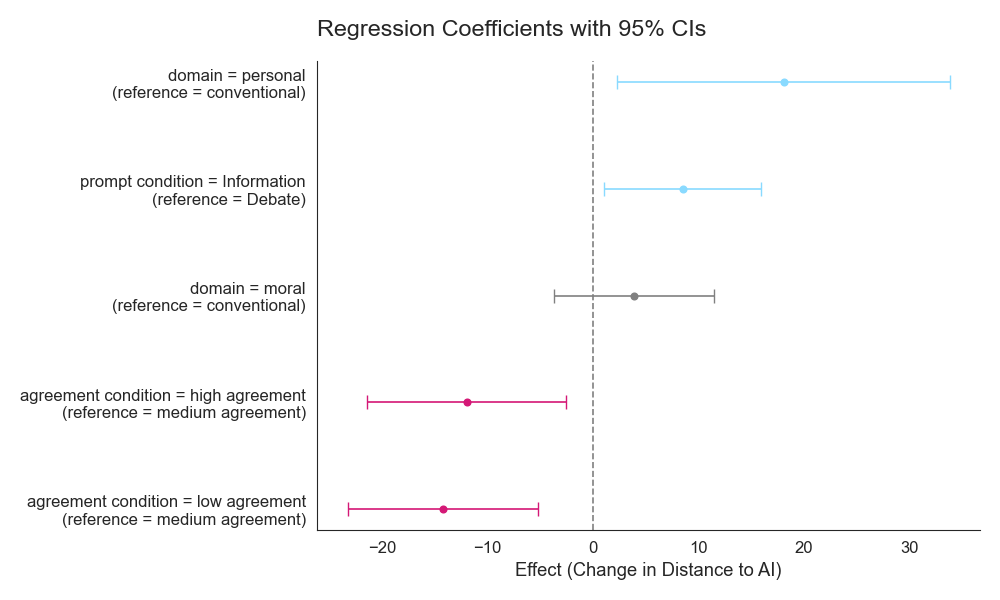

In [70]:
# Baseline model --- crossed random effects for person and stimulus
##########################################################################################
##########################################################################################

# https://github.com/statsmodels/statsmodels/issues/9279
formula = 'change_distance ~ C(domain, Treatment(reference="conventional")) + C(agreement_condition, Treatment(reference="medium_agreement")) + C(prompt_condition, Treatment(reference="Debate"))'
df['dummy'] = 1
model = MixedLM.from_formula(formula, data=df,
                             groups='dummy',
                             vc_formula={'id1': "0 + C(pid)",
                                         'id2': "0 + C(rot)"}
                                         )

result = model.fit()
print(result.summary())
from src.statsmodels_handler import StatsmodelsHandler, clean_var_name_from_formula
handler = StatsmodelsHandler(result)
handler.to_latex()
handler.plot(clean_var_name=clean_var_name_from_formula)
plt.xlabel("Effect (Change in Distance to AI)")
plt.ylabel("")
plt.title("Regression Coefficients with 95% CIs")
plt.show()

# Where are these changes coming from?

## Transition matrices

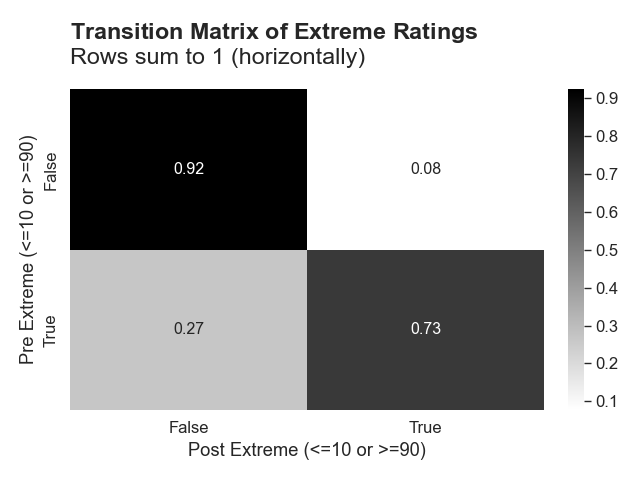

Text(0.0, 1.0, '$\\bf{Transition \\ Matrix \\ of \\ Rating \\ Buckets}$\nRows sum to 1 (horizontally)')

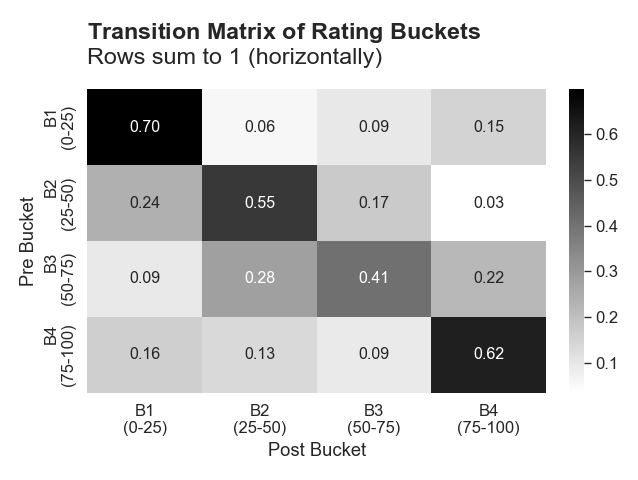

In [47]:
from src.helpers import make_aesthetic
mypal = make_aesthetic(font_scale=1.2)

def get_bucket_number(x):
    x = x.split("\n")[0][1:]
    return x

def is_extreme(x):
    return x < 10 or x > 90

def bucket_label(x, n_bins):
    bins = np.linspace(0, 100, n_bins + 1)
    labels = [f"B{i+1}\n({int(bins[i])}-{int(bins[i+1])})" for i in range(n_bins)]
    return pd.cut([x], bins=bins, labels=labels, include_lowest=True, ordered=True)[0]

df['pre_extreme'] = df['pre'].apply(is_extreme)
df['post_extreme'] = df['post'].apply(is_extreme)

####################################
# Transition matrix of extremes
####################################
sns.heatmap(
    pd.crosstab(df['pre_extreme'], df['post_extreme'], normalize='index'),
    annot=True, fmt=".2f", cmap="binary"
)
plt.xlabel("Post Extreme (<=10 or >=90)")
plt.ylabel("Pre Extreme (<=10 or >=90)")
plt.title(f"{make_bold("Transition Matrix of Extreme Ratings")}\nRows sum to 1 (horizontally)")
plt.show()


####################################
# Transition matrix of pre/post buckets
####################################
N_BINS=4
df['pre_bucket'] = df['pre'].apply(bucket_label, n_bins=N_BINS)
df['post_bucket'] = df['post'].apply(bucket_label, n_bins=N_BINS)
sns.heatmap(
    pd.crosstab(df['pre_bucket'], df['post_bucket'], normalize='index'),
    annot=True, fmt=".2f", cmap="binary"
)
plt.xlabel("Post Bucket")
plt.ylabel("Pre Bucket")
plt.title(f"{make_bold("Transition Matrix of Rating Buckets")}\nRows sum to 1 (horizontally)")
####################################

In [ ]:
pd.crosstab(df['pre_bucket'], df['post_bucket'])

## Effect size by (pre-exposure, AI rating) bins

Text(0, 0.5, 'Effect')

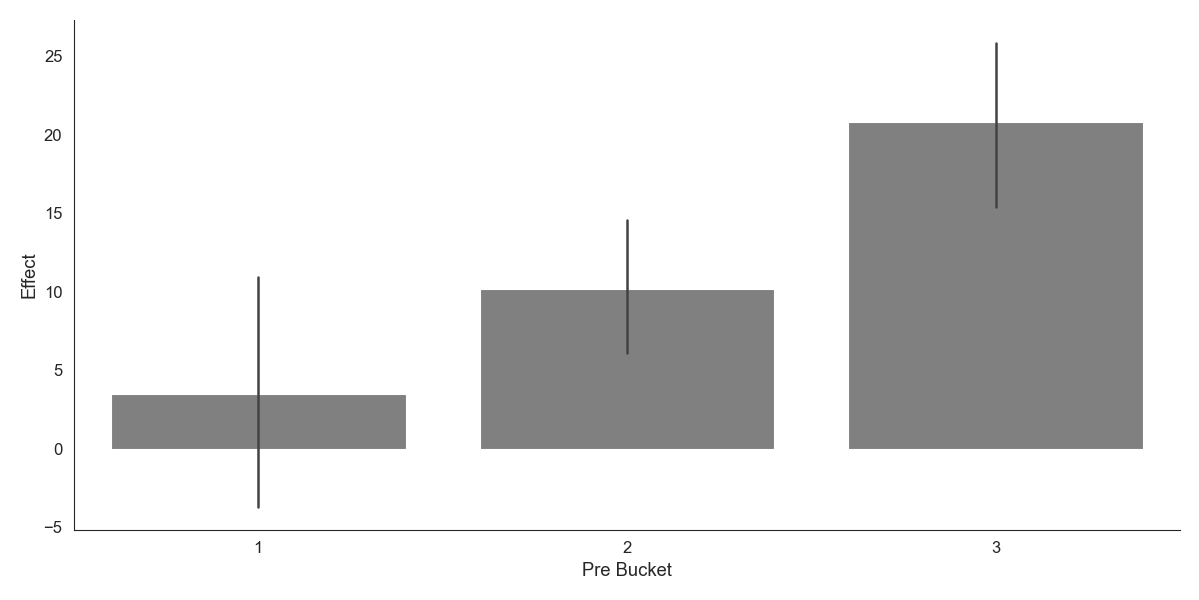

In [51]:
def get_bucket_number(x):
    x = x.split("\n")[0][1:]
    return x

N_BINS=3
df['pre_bucket'] = df['pre'].apply(bucket_label, n_bins=N_BINS)
df['post_bucket'] = df['post'].apply(bucket_label, n_bins=N_BINS)
df['pre_bucket_int'] = df['pre_bucket'].apply(get_bucket_number).astype(int)
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='pre_bucket_int', y='change_distance', color='gray')
# sns.lineplot(data=df, x='pre_bucket', y='change_distance', color='gray')
plt.xlabel("Pre Bucket")
plt.ylabel("Effect")


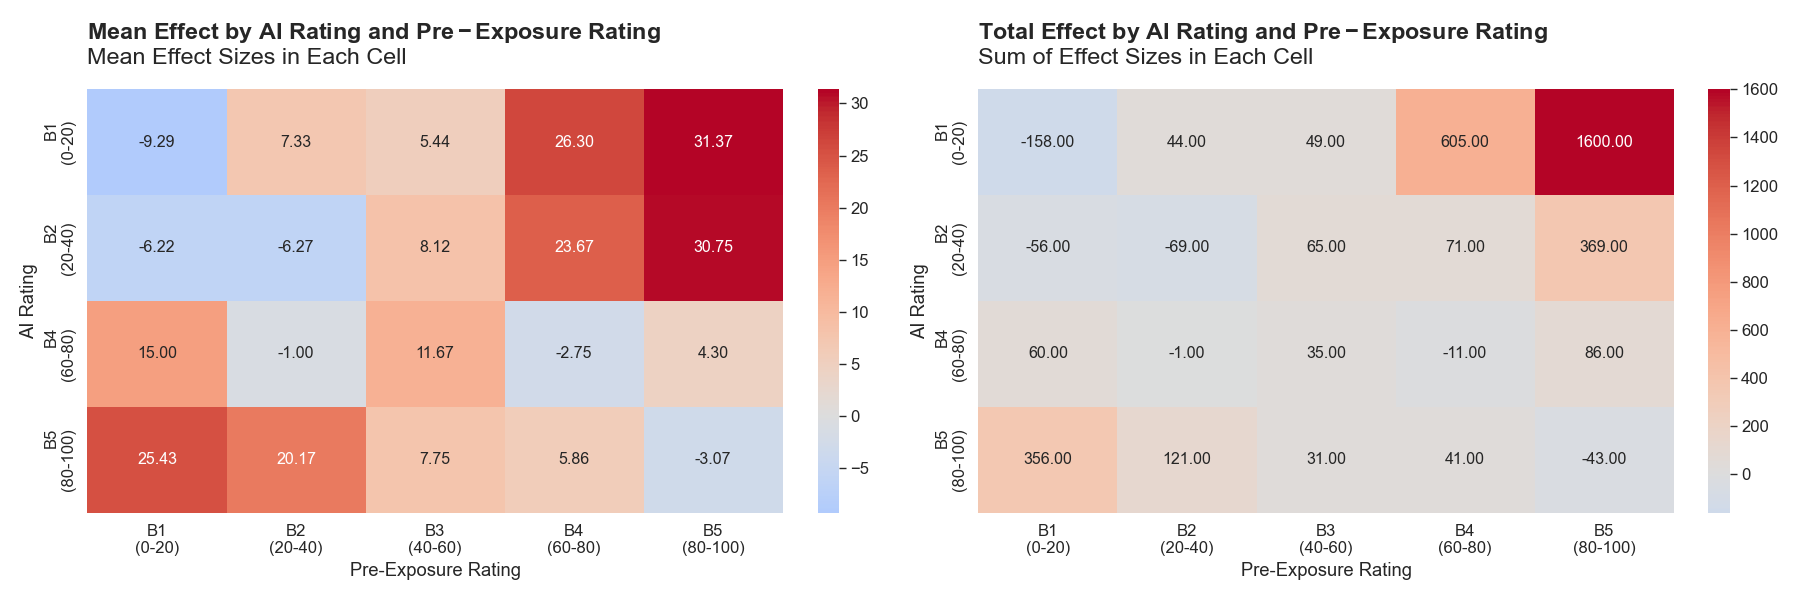

In [46]:
N_BINS = 5

df['rating_bucket'] = df['rating'].apply(bucket_label, n_bins=N_BINS)
df['rating_bucket_int'] = df['rating_bucket'].apply(get_bucket_number).astype(int)

df['pre_bucket'] = df['pre'].apply(bucket_label, n_bins=N_BINS)
df['pre_bucket_int'] = df['pre_bucket'].apply(get_bucket_number).astype(int)

# Get the sorted bucket categories
rating_order = [x for _, x in sorted(zip(df['rating_bucket_int'], df['rating_bucket'].astype(str).unique()), key=lambda t: int(get_bucket_number(t[1])))]
pre_order = [x for _, x in sorted(zip(df['pre_bucket_int'], df['pre_bucket'].astype(str).unique()), key=lambda t: int(get_bucket_number(t[1])))]



fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Mean of effects
heatmap_mean = df.pivot_table(index='rating_bucket', columns='pre_bucket', values='change_distance', aggfunc='mean')
heatmap_mean = heatmap_mean.reindex(index=rating_order, columns=pre_order)
sns.heatmap(heatmap_mean, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_xlabel("Pre-Exposure Rating")
axes[0].set_ylabel("AI Rating")
axes[0].set_title(f"{make_bold('Mean Effect by AI Rating and Pre-Exposure Rating')}\nMean Effect Sizes in Each Cell")

# Sum of effects
heatmap_sum = df.pivot_table(index='rating_bucket', columns='pre_bucket', values='change_distance', aggfunc='sum')
heatmap_sum = heatmap_sum.reindex(index=rating_order, columns=pre_order)
sns.heatmap(heatmap_sum, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_xlabel("Pre-Exposure Rating")
axes[1].set_ylabel("AI Rating")
axes[1].set_title(f"{make_bold('Total Effect by AI Rating and Pre-Exposure Rating')}\nSum of Effect Sizes in Each Cell")


plt.show()

## Denormalization vs Normalization

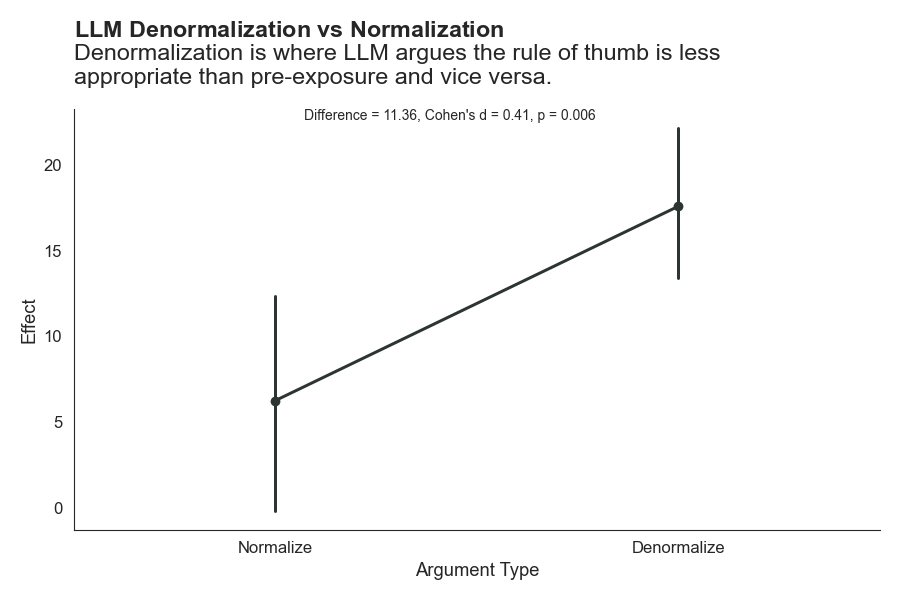

In [73]:
from scipy.stats import permutation_test

def cohens_d(x, y):
   nx, ny = len(x), len(y)
   pooled_std = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2))
   return (np.mean(x) - np.mean(y)) / pooled_std

def statistic(x, y):
   return np.mean(x) - np.mean(y)

df['convince_type'] = np.where(df['rating'] < df['pre'], "Denormalize", "Normalize")
denorm = df[df['convince_type'] == 'Denormalize']['change_distance']
norm = df[df['convince_type'] == 'Normalize']['change_distance']
cohens_d = cohens_d(denorm, norm)
res = permutation_test((denorm, norm), statistic, n_resamples=10000, alternative='two-sided', random_state=42)
plt.figure(figsize=(9, 6))
sns.pointplot(data=df, x='convince_type', y='change_distance')

plt.ylabel("Effect")
plt.xlabel("Argument Type")
plt.title(f"{make_bold('LLM Denormalization vs Normalization')}\nDenormalization is where LLM argues the rule of thumb is less\nappropriate than pre-exposure and vice versa.")
stats_dz_str = f"Difference = {res.statistic:.2f}, Cohen's d = {cohens_d:.2f}, p = {res.pvalue:.3f}"
plt.figtext(0.5, 0.8, stats_dz_str, ha="center", fontsize=10)
plt.show()

# Individual differences

<Axes: xlabel='change_distance', ylabel='pid'>

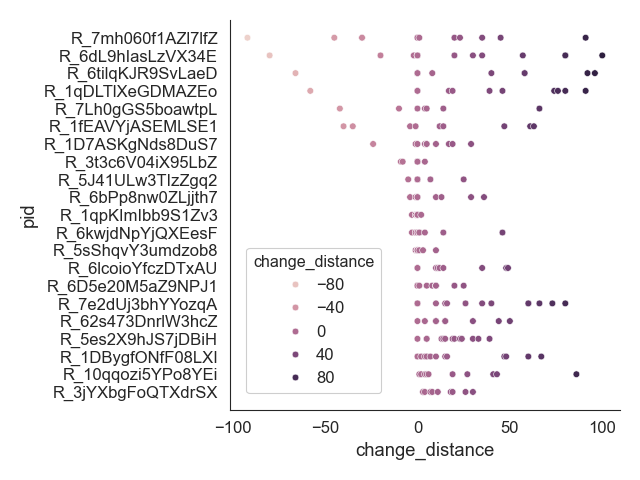

In [61]:
pid_cols = [c for c in df.columns if "usage" in c] + ["pid", "feedback"]

byp = (
    df.groupby(pid_cols)['change_distance']
      .agg(mean=np.mean, sd=np.std)
      .reset_index()
)
sns.scatterplot(data=df.sort_values(by=['change_distance']), y='pid', x='change_distance', hue='change_distance')


# How frequently do ppl use LLMs?

      usage_type  proportion    ci_low   ci_high  count  total
0       Personal    0.666667  0.354202  0.879416      6      9
1          Moral    0.666667  0.354202  0.879416      6      9
2   Conventional    0.555556  0.266651  0.811221      5      9
3  Any SSL Usage    0.666667  0.354202  0.879416      6      9


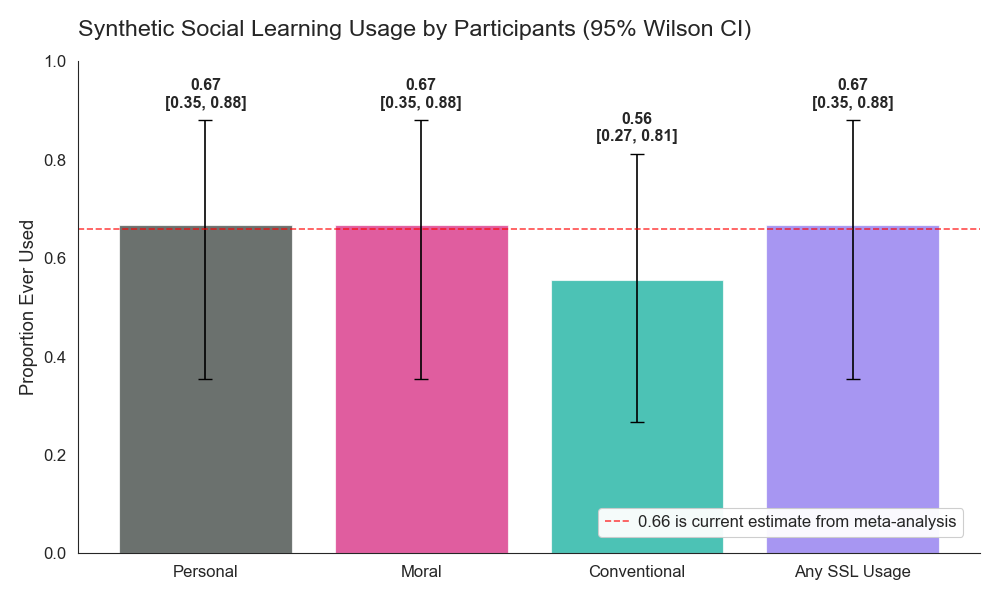

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint

from src.helpers import make_aesthetic


# Get color palette
mypal = make_aesthetic(font_scale=1.2)


# Create the any usage indicator
##################################################

byp['any_usage'] = ((byp['usage_personal_binary'] == 1) |
                   (byp['usage_moral_binary'] == 1) |
                   (byp['usage_convention_binary'] == 1)).astype(int)


# Get wilson CIs
##################################################
usage_vars = ['usage_personal_binary', 'usage_moral_binary', 'usage_convention_binary', 'any_usage']
labels = ['Personal', 'Moral', 'Conventional', 'Any SSL Usage']
summary_data = []
for var, label in zip(usage_vars, labels):
    count = byp[var].sum()
    total = len(byp)
    prop = count / total
    ci_low, ci_high = proportion_confint(count, total, method='wilson')

    summary_data.append({
        'usage_type': label,
        'proportion': prop,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'count': count,
        'total': total
    })

usage_df = pd.DataFrame(summary_data)
print(usage_df)


# Plot
##################################################
plt.figure(figsize=(10, 6))
bars = plt.bar(usage_df['usage_type'], usage_df['proportion'],
               color=mypal[:len(usage_df)], alpha=0.7)
errors = [usage_df['proportion'] - usage_df['ci_low'],
          usage_df['ci_high'] - usage_df['proportion']]
plt.errorbar(usage_df['usage_type'], usage_df['proportion'], yerr=errors,
             fmt='none', color='black', capsize=5)
for i, row in usage_df.iterrows():
    plt.text(i, row['ci_high'] + 0.02, f"{row['proportion']:.2f}\n[{row['ci_low']:.2f}, {row['ci_high']:.2f}]",
             ha='center', va='bottom', fontweight='bold')

plt.ylabel('Proportion Ever Used')
plt.axhline(y=0.66, color='red', linestyle='--', alpha=0.7, label="0.66 is current estimate from meta-analysis")
plt.legend(loc='lower right')
plt.title('Synthetic Social Learning Usage by Participants (95% Wilson CI)')
plt.ylim(0, 1)
plt.show()

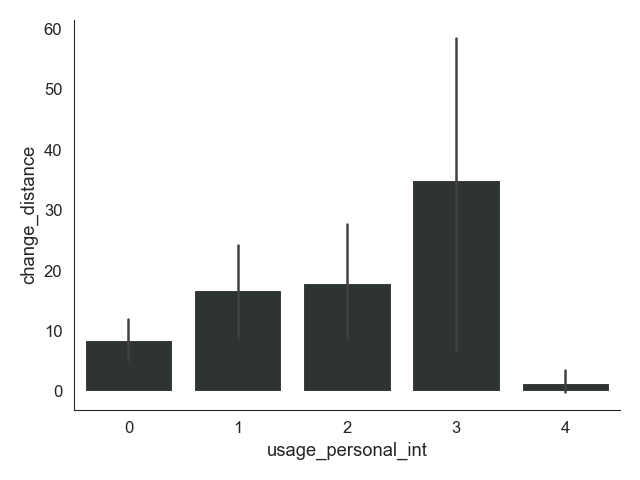

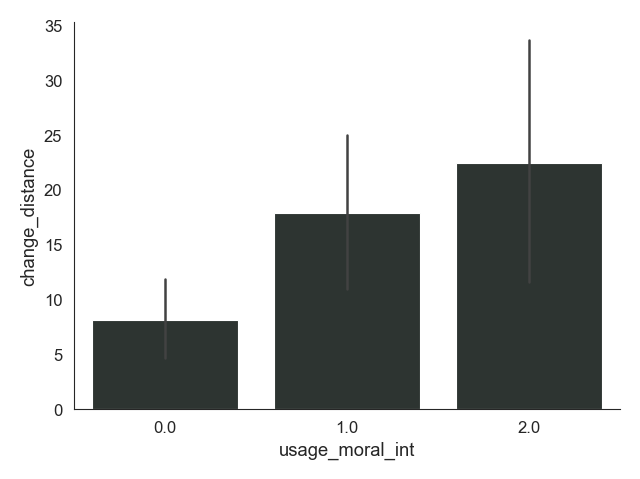

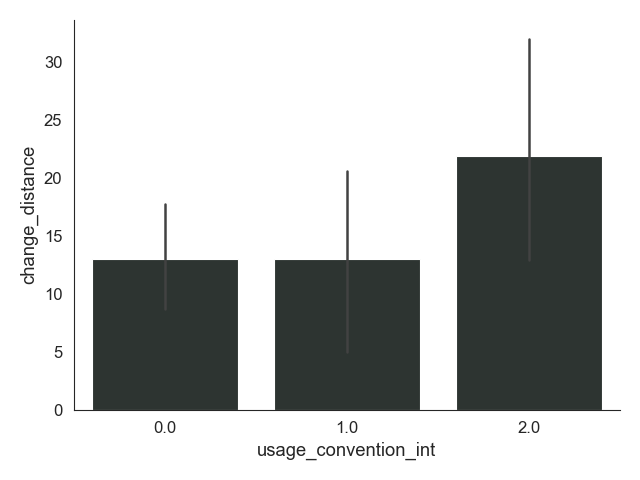

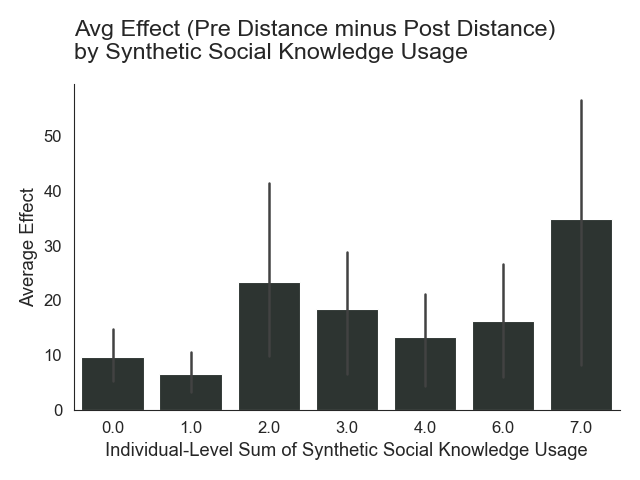

In [67]:
usage_map = {
   "No - never used": 0,
   "Yes - less often than several times a week": 1,
   "Yes - several times a week": 2,
   "Yes - about once a day": 3,
   "Yes - several times a day": 4
}

df['any_usage'] = ((df['usage_personal_binary'] == 1) |
                   (df['usage_moral_binary'] == 1) |
                   (df['usage_convention_binary'] == 1)).astype(int)

for var in ['usage_personal', 'usage_moral', 'usage_convention']:
    df[f"{var}_int"] = df[var].map(usage_map)
    sns.barplot(data=df, x=f"{var}_int", y='change_distance')
    plt.show()
df['usage_sum'] = df[['usage_personal_int', 'usage_moral_int', 'usage_convention_int']].sum(axis=1)

df['usage_mean'] = df[['usage_personal_int', 'usage_moral_int', 'usage_convention_int']].mean(axis=1)

sns.barplot(data=df, x='usage_sum', y='change_distance')
plt.xlabel("Individual-Level Sum of Synthetic Social Knowledge Usage")
plt.ylabel("Average Effect")
plt.title("Avg Effect (Pre Distance minus Post Distance)\nby Synthetic Social Knowledge Usage")
plt.show()

# Qual

## Overall feedback

In [68]:
for idx, row in byp.dropna(subset=['feedback']).sort_values(by=['mean'], ascending=False).iterrows():
    print(f"PID: {row['pid']}")
    print(f"Mean Change: {row['mean']:.2f}")
    print(f"Feedback: {row['feedback']}")
    print("====")


PID: R_1qDLTlXeGDMAZEo
Mean Change: 34.91
Feedback: No
====
PID: R_1DBygfONfF08LXI
Mean Change: 23.42
Feedback: I changed my mind a few times if I agreed with the reasoning. Other times, I simply didn't agree and stuck to my guns. 
====
PID: R_10qqozi5YPo8YEi
Mean Change: 23.40
Feedback: none. I found some of the explanations very helpful. They changed my mind at times
====
PID: R_6dL9hIasLzVX34E
Mean Change: 23.08
Feedback: In some cases I read the AI argument and I changed my mind as its argument I felt it is making sense.
====
PID: R_6lcoioYfczDTxAU
Mean Change: 19.89
Feedback: I seemed to be using "how reasonable" it was as my guide. If AI presented reasonable and logical arguments it changed my mind. 
====
PID: R_5es2X9hJS7jDBiH
Mean Change: 18.46
Feedback: I changed based on convincing points.
====
PID: R_6D5e20M5aZ9NPJ1
Mean Change: 7.62
Feedback: I think the last one about divorce, I was mainly thinking of how  weird it would feel but the AI explained many reasons why divorcees

## Trial level

In [75]:
from src.sbert_clusterer import SBERTClusterer
qdf = df.dropna(subset=['qual'])

qdf = df.dropna(subset=['qual']).copy()
qdf['change_distance_q'] = pd.qcut(qdf['change_distance'], 3).cat.codes + 1


clusterer = SBERTClusterer()
results = {}  # store results for each quartile bin

for q in sorted(qdf['change_distance_q'].unique()):
    print("="*80)
    print(f"Clustering for qcut bin: {q}")
    print("="*80)

    texts = qdf.loc[qdf['change_distance_q'] == q, 'qual'].tolist()

    if len(texts) < 2:
        print(f"Not enough texts for clustering in bin {q}. Skipping.")
        continue

    best_k = clusterer.find_k(texts, k_min=2, k_max=10, plot=False)

    clustered_df = clusterer.apply_clustering(texts, k=best_k)

    results[q] = {
        "best_k": best_k,
        "clustered_df": clustered_df,
        "summary": clusterer.get_cluster_summary()
    }



Clustering for qcut bin: 1
Best k: 6 with silhouette score: 0.035

Cluster 0 (Centroid: 'this a.i. is retarded.  how can this not be 100?'):
['WRONG!!!', 'Strange that it rated its agreement as only 76 considering it had so much positive to say about it', 'this a.i. is retarded.  how can this not be 100?']

Cluster 1 (Centroid: 'This rule is a classic paradox between personal obligation and individual autonomy. While it is ethically and legally the parent's responsibility to care for their child, the rule implies that a sibling, despite having their own life and boundaries, must find a replacement caregiver. This places an undue burden on a person who is acting out of kindness and family loyalty, but is not legally or financially responsible. It conflates help with an unbreakable, permanent obligation.  From a utilitarian perspective, this rule might seem to benefit the children by ensuring their care, but it does so at the potential expense of the caregiver's well-being and personal l

# Spaghetti plot

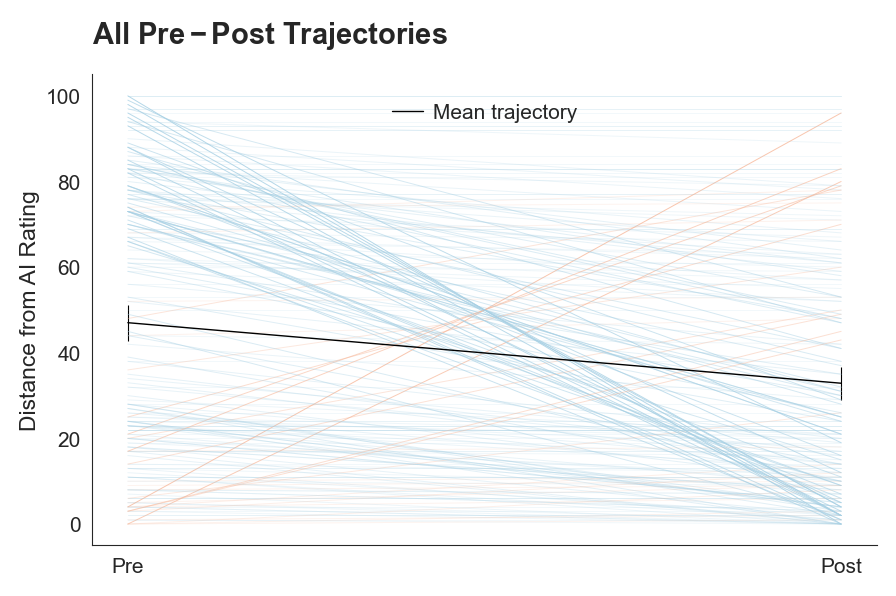

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

make_aesthetic(font_scale=1.5)
fig, ax = plt.subplots(figsize=(9, 6))

# make the lines
colors = sns.color_palette("RdBu_r", 2)
dec_color, inc_color = colors[0], colors[1]
max_change = df['change_distance'].abs().max()
for i in range(len(df)):
    pre_val = df['pre_distance'].iloc[i]
    post_val = df['post_distance'].iloc[i]
    change = post_val - pre_val
    color = inc_color if change > 0 else dec_color
    ax.plot([0, 1], [pre_val, post_val],
            color=color,
            alpha=0.15 + 0.7 * (abs(change) / max_change),
            linewidth=0.7)

# Mean trajectory
mean_pre = df['pre_distance'].mean()
mean_post = df['post_distance'].mean()
ax.plot([0, 1], [mean_pre, mean_post],
        color="black", linewidth=1, label="Mean trajectory")

# Confidence intervals
ci_pre = (df['pre_distance'].mean() - 1.96*df['pre_distance'].std()/np.sqrt(len(df)),
          df['pre_distance'].mean() + 1.96*df['pre_distance'].std()/np.sqrt(len(df)))
ci_post = (df['post_distance'].mean() - 1.96*df['post_distance'].std()/np.sqrt(len(df)),
           df['post_distance'].mean() + 1.96*df['post_distance'].std()/np.sqrt(len(df)))
ax.fill_between([0, 0], ci_pre[0], ci_pre[1], color="black", alpha=1)
ax.fill_between([1, 1], ci_post[0], ci_post[1], color="black", alpha=1)


title = f"{make_bold('All Pre-Post Trajectories')}"
ax.set_xticks([0, 1])
ax.set_xticklabels(["Pre", "Post"])
ax.set_ylabel("Distance from AI Rating")
ax.set_title(title)
ax.legend(frameon=False)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()


# For what things did ppl change?

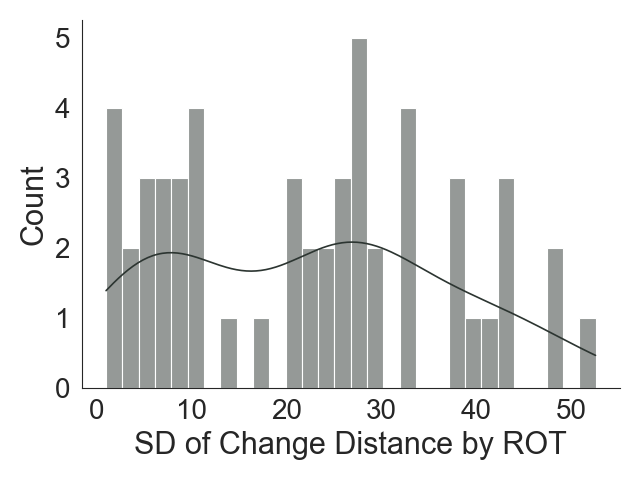

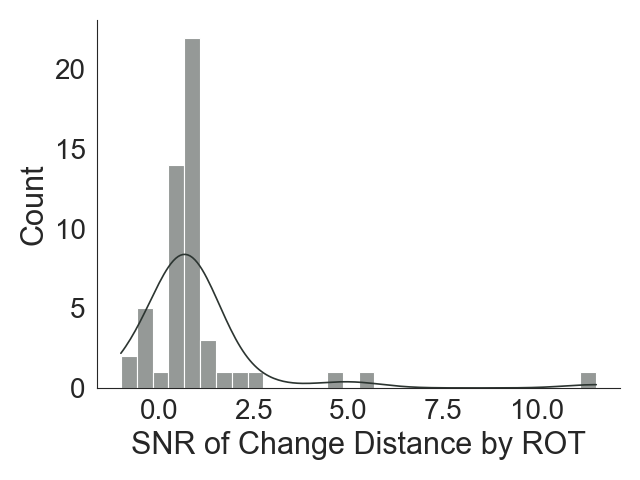

In [52]:
byr = df.groupby(by=['rot'])[['pre_distance', 'post_distance', 'change_distance', 'rating']].agg(['mean', 'std']).reset_index().dropna()
byr.columns = ['_'.join(col).strip() if col[1] else col[0] for col in byr.columns.values]
byr['snr'] = byr['change_distance_mean'] / byr['change_distance_std']

sns.histplot(byr['change_distance_std'], bins=30, kde=True)
plt.xlabel("SD of Change Distance by ROT")
plt.show()

sns.histplot(byr['snr'], bins=30, kde=True)
plt.xlabel("SNR of Change Distance by ROT")
plt.show()

In [49]:
byr['snr'].describe()

count    53.000000
mean      1.017275
std       1.807885
min      -1.000000
25%       0.478919
50%       0.693761
75%       0.959351
max      11.549411
Name: snr, dtype: float64

## Double click on high SNR items (mean/sd > 1)

In [58]:
for idx, row in byr.query("snr > 1").iterrows():
    print(f"ROT: {row['rot']}, RATING: {row['rating_mean']:.2f}, SNR: {row['snr']:.2f}, Mean Change: {row['change_distance_mean']:.2f}, SD Change: {row['change_distance_std']:.2f}")
    rot_df = df.query("rot == @row['rot']")
    for _, r in rot_df.iterrows():
        print(f"  PID: {r['pid']}, Pre: {r['pre']:.2f}, Post: {r['post']:.2f}, Change: {r['change_distance']:.2f}, Qual: {r['qual']}")
    print("===")

ROT: If you cannot get someone to remove you from a contract you are expected to call an attorney., RATING: 2.00, SNR: 5.27, Mean Change: 39.00, SD Change: 7.39
  PID: R_62s473DnrlW3hcZ, Pre: 99.00, Post: 55.00, Change: 44.00, Qual: nan
  PID: R_6bPp8nw0ZLjjth7, Pre: 86.00, Post: 50.00, Change: 36.00, Qual: Though those options do exist, if the person is refusing to remove you from a contract it's doubtful they will agree to using legal zoom or mediation. 
  PID: R_5es2X9hJS7jDBiH, Pre: 80.00, Post: 50.00, Change: 30.00, Qual: nan
  PID: R_6kwjdNpYjQXEesF, Pre: 89.00, Post: 43.00, Change: 46.00, Qual: nan
===
ROT: If your sister is not able to take care of her kids on her own and you no longer want to do it you need to find someone else to take care of them., RATING: 3.00, SNR: 1.44, Mean Change: 32.75, SD Change: 22.69
  PID: R_6lcoioYfczDTxAU, Pre: 76.00, Post: 27.00, Change: 49.00, Qual: AI changed my mind, I didn't think my answer through and AI helped me change my mind
  PID: R_5s

<Axes: xlabel='rating', ylabel='change_distance'>

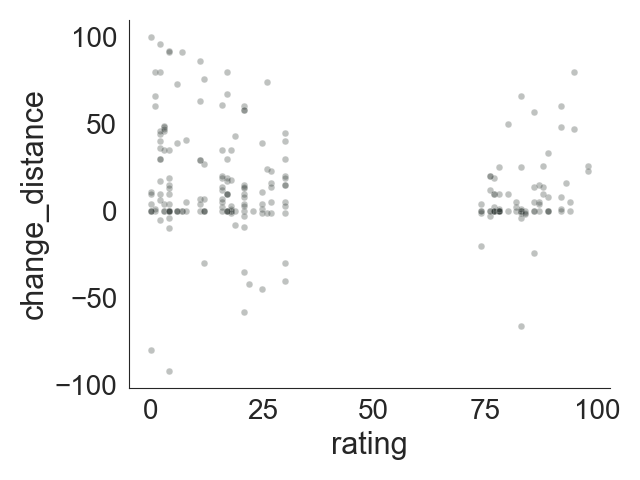

In [57]:
sns.scatterplot(data=df, x='rating', y='change_distance', alpha=0.3)

# Feedback at end

In [81]:
end_df = df.groupby(by=['pid', 'feedback'])['change_distance'].mean().reset_index()
for idx, row in end_df.dropna(subset=['feedback']).sort_values(by=['change_distance'], ascending=False).iterrows():
    print(f"PID: {row['pid']}")
    print(f"Mean Change: {row['change_distance']:.2f}")
    print(f"Feedback: {row['feedback']}")
    print("====")

PID: R_1qDLTlXeGDMAZEo
Mean Change: 34.91
Feedback: No
====
PID: R_1DBygfONfF08LXI
Mean Change: 23.42
Feedback: I changed my mind a few times if I agreed with the reasoning. Other times, I simply didn't agree and stuck to my guns. 
====
PID: R_10qqozi5YPo8YEi
Mean Change: 23.40
Feedback: none. I found some of the explanations very helpful. They changed my mind at times
====
PID: R_6dL9hIasLzVX34E
Mean Change: 23.08
Feedback: In some cases I read the AI argument and I changed my mind as its argument I felt it is making sense.
====
PID: R_6lcoioYfczDTxAU
Mean Change: 19.89
Feedback: I seemed to be using "how reasonable" it was as my guide. If AI presented reasonable and logical arguments it changed my mind. 
====
PID: R_5es2X9hJS7jDBiH
Mean Change: 18.46
Feedback: I changed based on convincing points.
====
PID: R_6D5e20M5aZ9NPJ1
Mean Change: 7.62
Feedback: I think the last one about divorce, I was mainly thinking of how  weird it would feel but the AI explained many reasons why divorcees